# Instant Model Experiments (Linear Regression)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` as a number.
We split into train/val/test and evaluate with MAE and R2.

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [18]:
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

target_col = 'comfortValue'
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

missing_cols = [col for col in [target_col] + feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df = df[feature_cols + [target_col]].copy()
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna()

print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue
0,4225.0,7.669843,25.1,7.810250,0.001916,4
1,4225.0,7.669843,25.1,7.810250,0.001916,5
2,4096.0,6.835845,25.2,7.810250,0.001976,3
3,4096.0,6.835845,25.2,7.810250,0.001976,4
4,3969.0,7.039566,25.3,7.745967,0.001938,4


In [19]:
X = df[feature_cols]
y = df[target_col]

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 1,449
Test size:  363


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept': [True, False]
}

lr = LinearRegression()

grid = GridSearchCV(
    lr, 
    param_grid=param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=5, 
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV MAE: {-grid.best_score_:.3f}")

best_model = grid.best_estimator_

Best params: {'fit_intercept': True}
Best CV MAE: 0.723


Test MAE: 0.749 | R2: 0.028



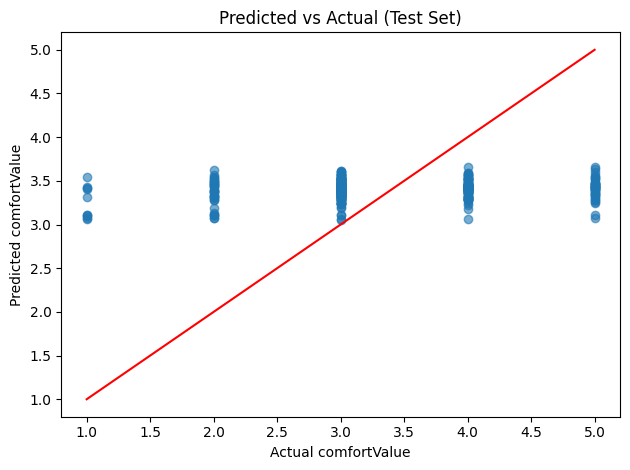

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

test_preds = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)
print(f"Test MAE: {test_mae:.3f} | R2: {test_r2:.3f}\n")

plt.scatter(y_test, test_preds, alpha=0.6)
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.title('Predicted vs Actual (Test Set)')
plt.xlabel('Actual comfortValue')
plt.ylabel('Predicted comfortValue')
plt.tight_layout()
plt.show()